In [46]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd
import ROOT
from scipy.optimize import curve_fit

In [13]:
file = ROOT.TFile.Open("../DetectorSimulation/output/default.root")

In [14]:
tracks = file.Get("tracks")
tracks.Print()

******************************************************************************
*Tree    :tracks    : Track parameters                                       *
*Entries :   500000 : Total =       111469745 bytes  File  Size =   78857803 *
*        :          : Tree compression factor =   1.41                       *
******************************************************************************
*Br    0 :MomentumX : Double_t tracks                                        *
*Entries :   500000 : Total  Size=    6014628 bytes  File Size  =    4481081 *
*Baskets :      130 : Basket Size=      32000 bytes  Compression=   1.34     *
*............................................................................*
*Br    1 :MomentumY : Double_t tracks                                        *
*Entries :   500000 : Total  Size=    6014628 bytes  File Size  =    4480888 *
*Baskets :      130 : Basket Size=      32000 bytes  Compression=   1.34     *
*...................................................

In [15]:
num_tracks = tracks.GetEntries()

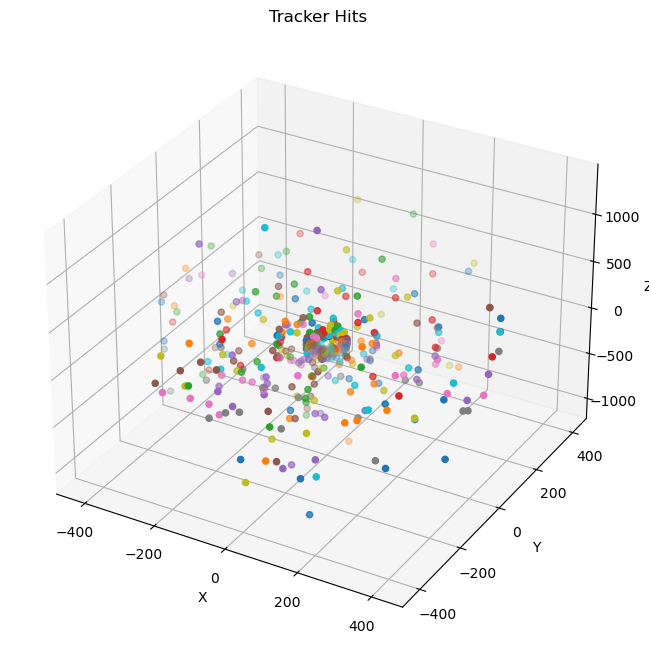

In [16]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Tracker Hits')

for i in range(100):
    tracks.GetEntry(i)
    x = np.array(tracks.HitPositionX)
    y = np.array(tracks.HitPositionY)
    z = np.array(tracks.HitPositionZ)
    ax.scatter(x, y, z)

plt.show()

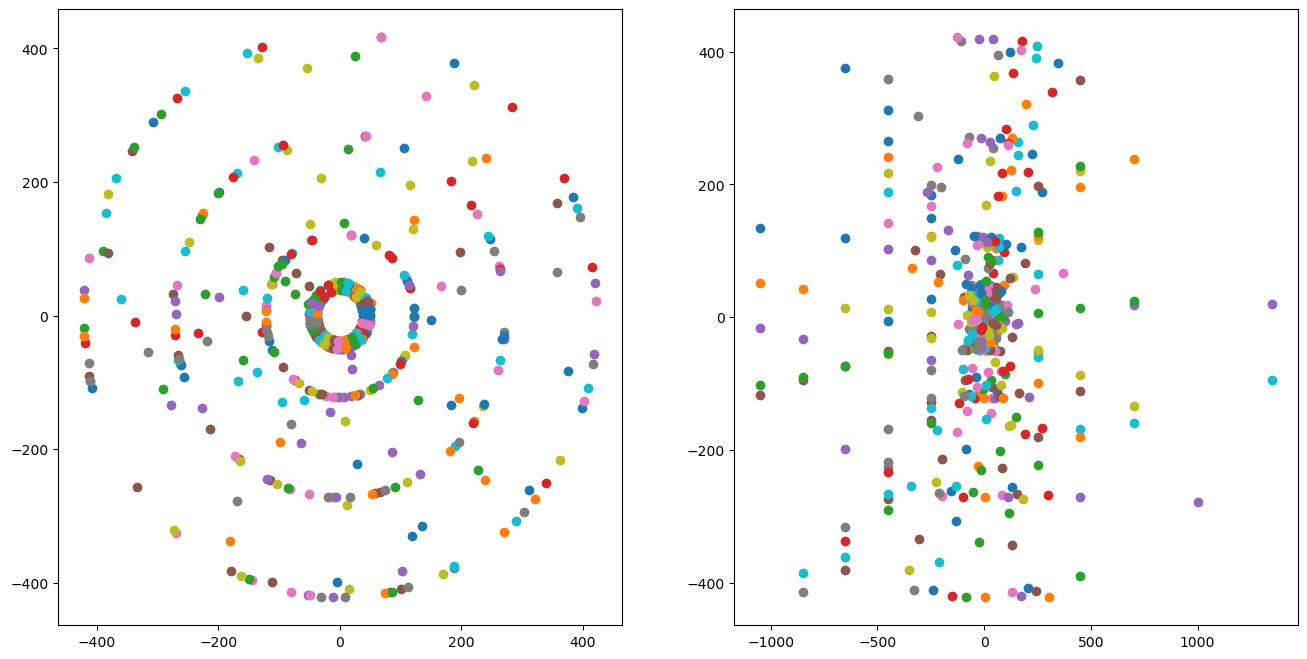

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for i in range(100):
    tracks.GetEntry(i)
    x = np.array(tracks.HitPositionX)
    y = np.array(tracks.HitPositionY)
    z = np.array(tracks.HitPositionZ)
    axes[0].scatter(x, y)
    axes[1].scatter(z, x)

plt.show()

In [18]:
# for track in list(track_hits.values())[:100]:
#     x, y, z = zip(*track)
#     z = np.array(z)
#     z_scaled = (z - z[0]) / (z[-1] - z[0])
#     plt.plot(np.arange(len(z)), z)

# plt.show()

# First we cheat and skip the track finding step, and simply fit tracks

In [19]:
# num_hits_per_track = {}

# for eventID in track_hits:
#     num_hits_per_track[eventID] = len(track_hits[eventID])

# plt.hist(num_hits_per_track.values(), bins=max())
# plt.xlim(0, 20)

In [20]:
from helix_fitting import fit_helix, momentum_from_helix, DCA_from_helix, RMSE, helix

In [21]:
B = 1.7

cutoff_momentum = 50_000 # 50 MeV
cutoff_RMSE = 3

data = []

for i in range(num_tracks):
    tracks.GetEntry(i)
    if tracks.NumHits < 4:
        continue
    x = np.array(tracks.HitPositionX)
    y = np.array(tracks.HitPositionY)
    z = np.array(tracks.HitPositionZ)
    x_c, y_c, R, tanl, z0, phi = fit_helix(x, y, z)

    fitted_pT, fitted_pZ = momentum_from_helix(R, tanl, B)
    fitted_p = np.sqrt(fitted_pT ** 2 + fitted_pZ ** 2)
    fitted_DCA = DCA_from_helix(x_c, y_c, R)

    pX, pY, pZ = tracks.MomentumX, tracks.MomentumY, tracks.MomentumZ
    p = np.sqrt(pX ** 2 + pY ** 2 + pZ ** 2)
    pT = np.sqrt(pX ** 2 + pY ** 2)
    eta = np.arctanh(pZ / p)

    delta_p = (fitted_p - p) / p
    delta_pT = (fitted_pT - pT) / pT 

    error = RMSE(x, y, z, x_c, y_c, z0, fitted_pZ, fitted_pT, R)

    if fitted_p > cutoff_momentum:
        continue

    data.append({
        "True Momentum (MeV/c)": round(p),
        "True Transverse Momentum (MeV/c)": pT,
        "True Z Momentum (MeV/c)": pZ,
        "Fitted Momentum (MeV/c)": fitted_p,
        "Fitted Transverse Momentum (MeV/c)": fitted_pT,
        "Fitted Z Momentum (MeV/c)": fitted_pZ,
        "Pseudorapidity": eta,
        "DCA (mm)": fitted_DCA
    })

df = pd.DataFrame(data)
df.head()

,True Momentum (MeV/c),True Transverse Momentum (MeV/c),True Z Momentum (MeV/c),Fitted Momentum (MeV/c),Fitted Transverse Momentum (MeV/c),Fitted Z Momentum (MeV/c),Pseudorapidity,DCA (mm)
0,500,451.744107,214.306467,498.586059,449.944452,-214.797694,0.458196,0.019325
1,500,454.441433,208.525740,498.643029,453.715328,-206.850843,0.444117,0.003964
2,700,469.321697,519.362248,699.144523,467.719803,-519.654934,0.954795,0.112657
3,5000,4701.210612,-1702.533050,5005.676703,4706.959101,1703.330642,-0.354665,0.010375
4,500,431.350178,252.857714,499.816765,430.641319,-253.702291,0.556956,0.099995


array([[<Axes: title={'center': 'True Momentum (MeV/c)'}>,
        <Axes: title={'center': 'True Transverse Momentum (MeV/c)'}>,
        <Axes: title={'center': 'True Z Momentum (MeV/c)'}>],
       [<Axes: title={'center': 'Fitted Momentum (MeV/c)'}>,
        <Axes: title={'center': 'Fitted Transverse Momentum (MeV/c)'}>,
        <Axes: title={'center': 'Fitted Z Momentum (MeV/c)'}>],
       [<Axes: title={'center': 'Pseudorapidity'}>,
        <Axes: title={'center': 'DCA (mm)'}>, <Axes: >]], dtype=object)

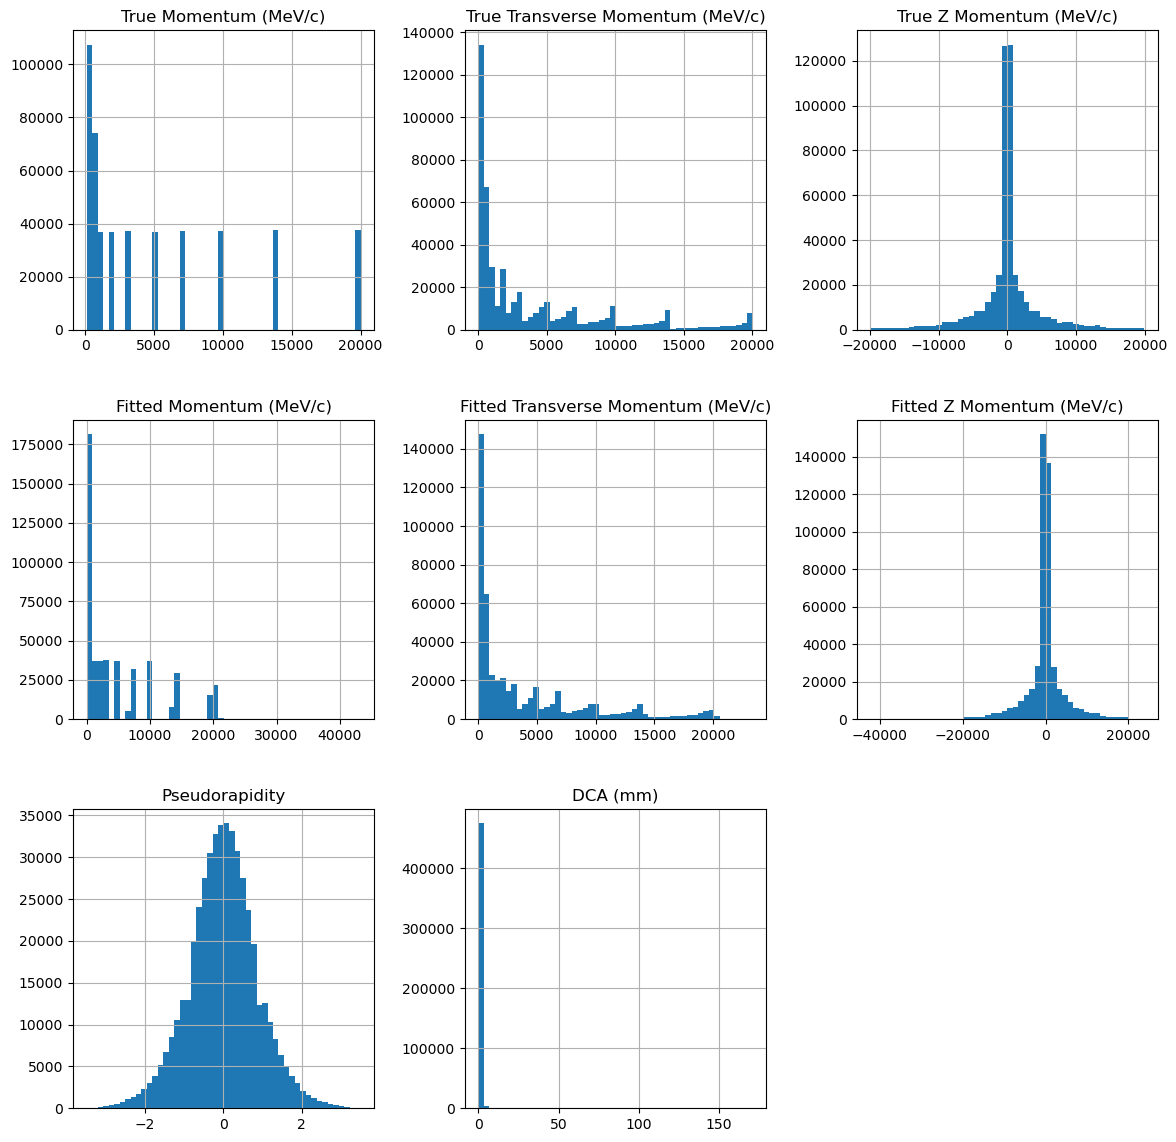

In [25]:
df.hist(bins=50, figsize=(14, 14))

In [48]:
def gaussian(x, A, x_0, sigma):
    return A * np.exp(-(x - x_0)**2 / (2 * sigma**2))

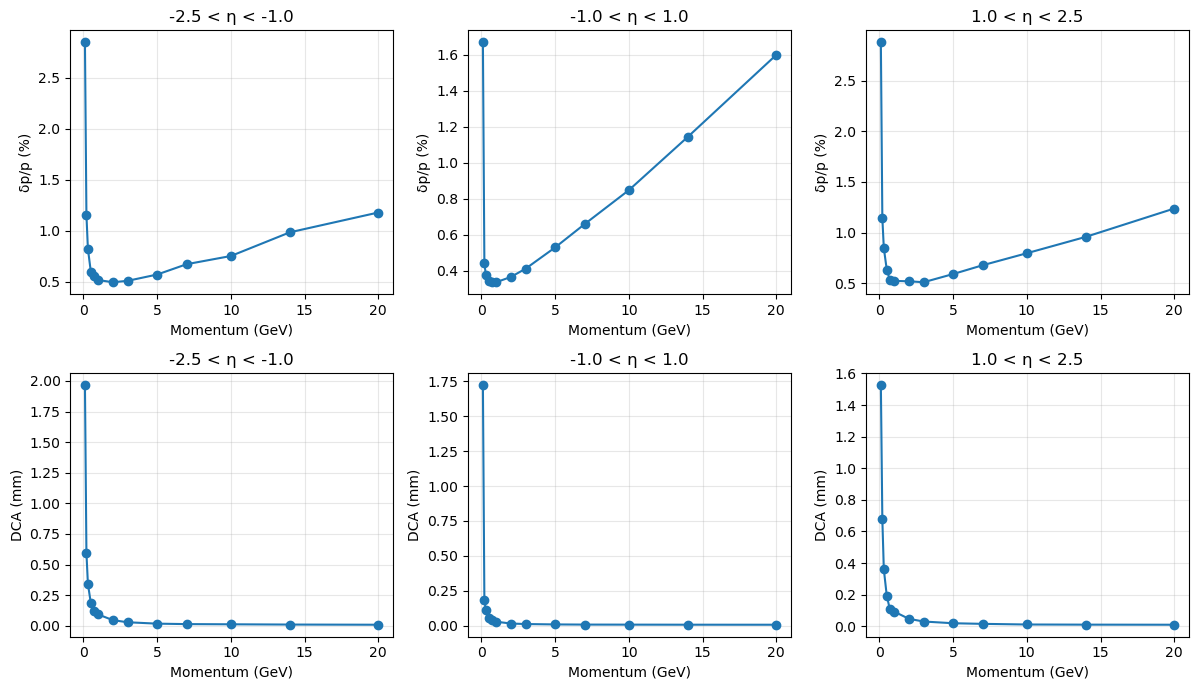

In [66]:
fig, axes = plt.subplots(2, 3, figsize=(12, 7))

eta_bins = [
    (-2.5, -1.0),
    (-1.0,  1.0),
    ( 1.0,  2.5),
]

for i, (eta_lo, eta_hi) in enumerate(eta_bins):
    df_eta = df[(df["Pseudorapidity"] >= eta_lo) &
                (df["Pseudorapidity"] < eta_hi)]
    
    momentum_points = sorted(df_eta["True Momentum (MeV/c)"].unique())

    p_GeV = []
    sigma_delta_pT = []
    mean_DCA = []

    for p in momentum_points[:]:
        subset = df_eta[df_eta["True Momentum (MeV/c)"] == p]
        p_GeV.append(p / 1000)

        pT_residual = (subset["Fitted Transverse Momentum (MeV/c)"] - subset["True Transverse Momentum (MeV/c)"]) / subset["True Transverse Momentum (MeV/c)"]
        sigma_guess = (np.percentile(pT_residual, 84) - np.percentile(pT_residual, 16)) / 2
        
        counts, edges = np.histogram(pT_residual, bins=50, range=(-sigma_guess * 2, sigma_guess * 2))
        mids = (edges[:-1] + edges[1:]) / 2

        popt, _ = curve_fit(gaussian, mids, counts, p0=[max(counts), 0, sigma_guess])
        sigma_delta_pT.append(abs(popt[2]))     

        mean_DCA.append(subset["DCA (mm)"].mean())


    axes[0, i].plot(p_GeV, np.array(sigma_delta_pT) * 100, marker="o")

    axes[0, i].set_title(f"{eta_lo} < η < {eta_hi}")
    axes[0, i].set_xlabel("Momentum (GeV)")
    axes[0, i].set_ylabel("δp/p (%)")
    axes[0, i].grid(alpha=0.3)

    axes[1, i].plot(p_GeV, mean_DCA, marker="o")

    axes[1, i].set_title(f"{eta_lo} < η < {eta_hi}")
    axes[1, i].set_xlabel("Momentum (GeV)")
    axes[1, i].set_ylabel("DCA (mm)")
    axes[1, i].grid(alpha=0.3)


plt.tight_layout()
plt.show()

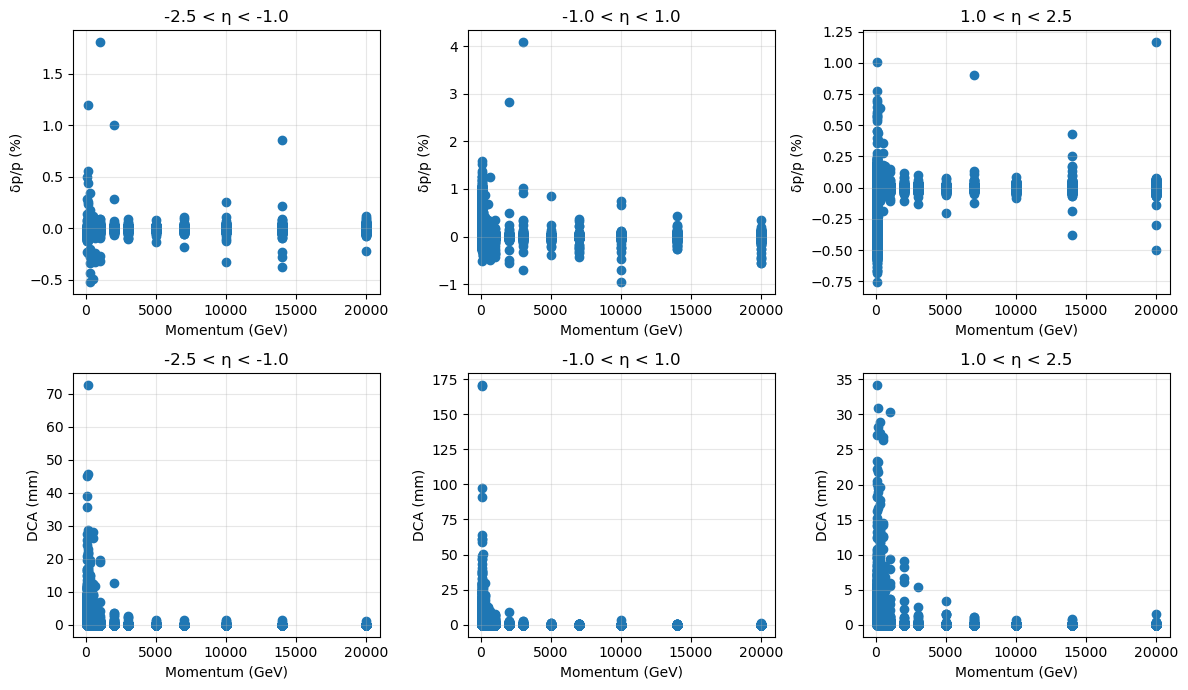

In [69]:
fig, axes = plt.subplots(2, 3, figsize=(12, 7))

eta_bins = [
    (-2.5, -1.0),
    (-1.0,  1.0),
    ( 1.0,  2.5),
]

for i, (eta_lo, eta_hi) in enumerate(eta_bins):
    df_eta = df[(df["Pseudorapidity"] >= eta_lo) &
                (df["Pseudorapidity"] < eta_hi)]
    
    momentum_points = sorted(df_eta["True Momentum (MeV/c)"].unique())

    p_residual = (df_eta["Fitted Momentum (MeV/c)"] - df_eta["True Momentum (MeV/c)"]) / df_eta["True Momentum (MeV/c)"]

    axes[0, i].scatter(df_eta["True Momentum (MeV/c)"], p_residual)
    axes[1, i].scatter(df_eta["True Momentum (MeV/c)"], df_eta["DCA (mm)"])

    axes[0, i].set_title(f"{eta_lo} < η < {eta_hi}")
    axes[0, i].set_xlabel("Momentum (GeV)")
    axes[0, i].set_ylabel("δp/p (%)")
    axes[0, i].grid(alpha=0.3)

    axes[1, i].set_title(f"{eta_lo} < η < {eta_hi}")
    axes[1, i].set_xlabel("Momentum (GeV)")
    axes[1, i].set_ylabel("DCA (mm)")
    axes[1, i].grid(alpha=0.3)

plt.tight_layout()
plt.show()

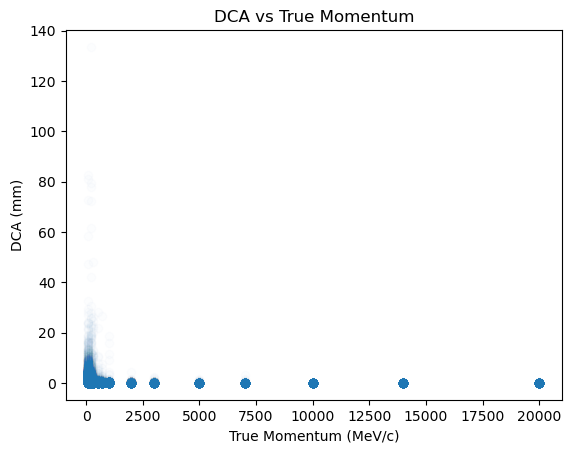

In [ ]:
plt.scatter(df["Momentum (MeV/c)"], df["DCA (mm)"], alpha=0.01)
plt.xlabel("True Momentum (MeV/c)")
plt.ylabel("DCA (mm)")
plt.title("DCA vs True Momentum")
plt.show()

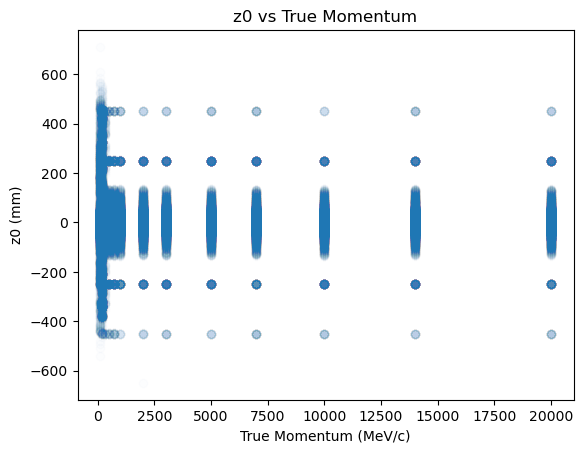

In [ ]:
plt.scatter(df["Momentum (MeV/c)"], df["z0 (mm)"], alpha=0.01)
plt.xlabel("True Momentum (MeV/c)")
plt.ylabel("z0 (mm)")
plt.title("z0 vs True Momentum")
plt.show()

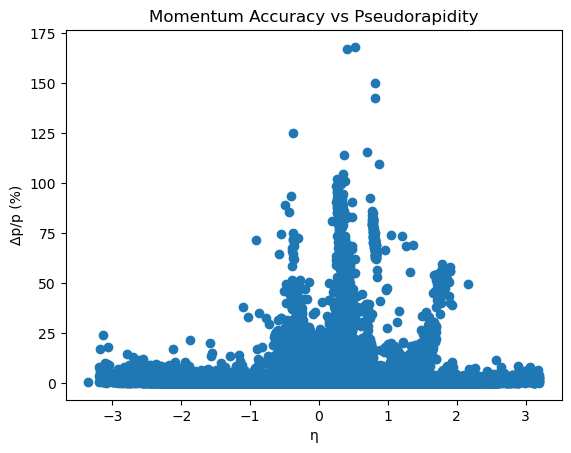

In [ ]:
plt.scatter(df["Pseudorapidity"], df["Momentum Accuracy (%)"])
plt.xlabel("η")
plt.ylabel("Δp/p (%)")
plt.title("Momentum Accuracy vs Pseudorapidity")
plt.show()

[]

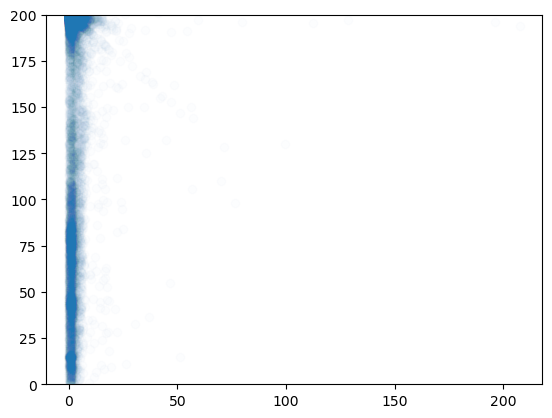

In [ ]:
plt.scatter(df["Transverse Momentum Accuracy (%)"], df["Z Momentum Accuracy (%)"], alpha=0.01)
plt.ylim(0, 200)
plt.plot()

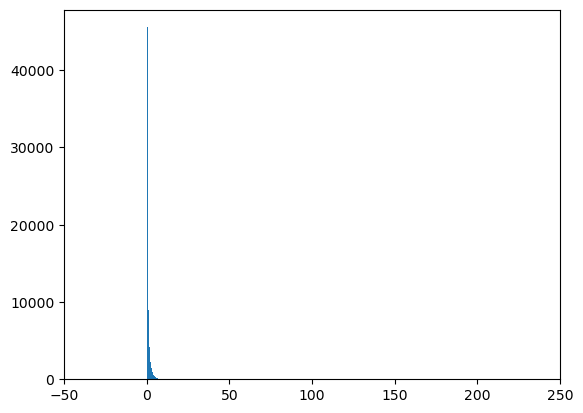

In [ ]:
plt.hist(df["Z Momentum Accuracy (%)"], bins=np.arange(0, 300, 0.5))
plt.xlim(-50, 250)
plt.show()

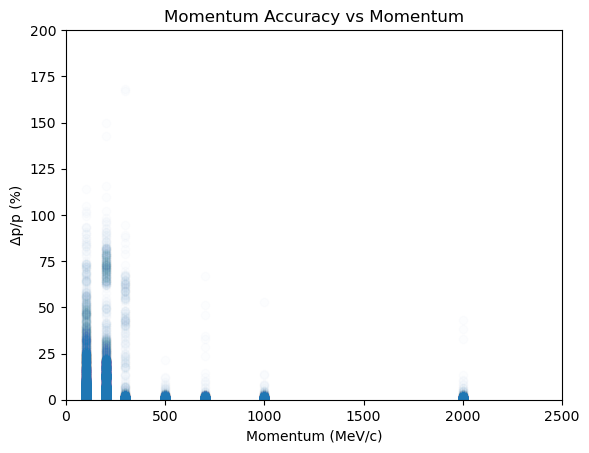

In [ ]:
plt.scatter(df["Momentum (MeV/c)"], df["Momentum Accuracy (%)"], alpha=0.01)
plt.xlabel("Momentum (MeV/c)")
plt.ylabel("Δp/p (%)")
plt.title("Momentum Accuracy vs Momentum")
plt.ylim(0, 200)
plt.xlim(0, 2500)
plt.show()

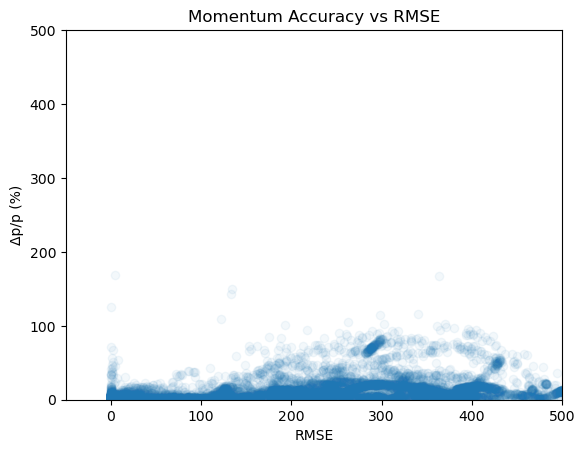

In [ ]:
plt.scatter(df["RMSE"], df["Momentum Accuracy (%)"], alpha=0.05)
plt.xlabel("RMSE")
plt.ylabel("Δp/p (%)")
plt.title("Momentum Accuracy vs RMSE")
plt.ylim(0, 500)
plt.xlim(-50, 500)
plt.show()

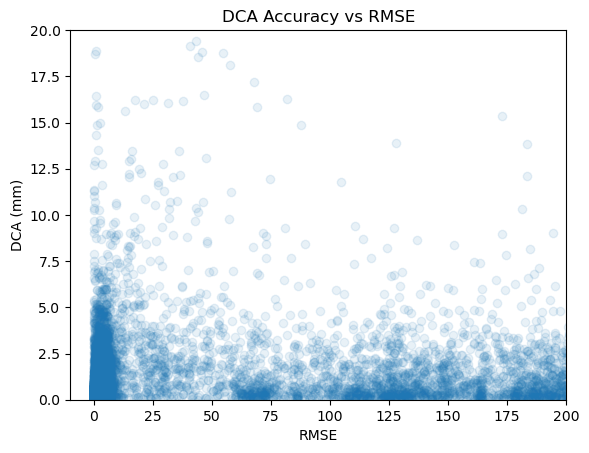

In [ ]:
plt.scatter(df["RMSE"], df["DCA (mm)"], alpha=0.1)
plt.xlabel("RMSE")
plt.ylabel("DCA (mm)")
plt.title("DCA Accuracy vs RMSE")
plt.ylim(0, 20)
plt.xlim(-10, 200)
plt.show()

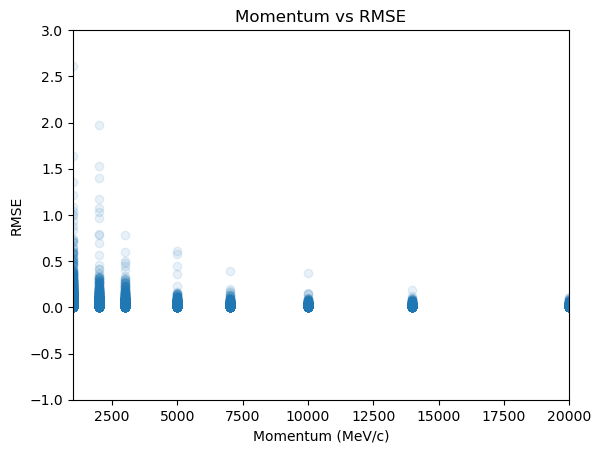

In [ ]:
plt.scatter( df["Momentum (MeV/c)"], df["RMSE"], alpha=0.1)
plt.xlabel("Momentum (MeV/c)")
plt.ylabel("RMSE")
plt.title("Momentum vs RMSE")
plt.xlim(1000, 20000)
plt.ylim(-1, 3)
plt.show()

In [ ]:
df.sort_values(by="Momentum Accuracy (%)", ascending=False).head(100)

,EventID,Momentum (MeV/c),Transverse Momentum (MeV/c),Z Momentum (MeV/c),Pseudorapidity,Momentum Accuracy (%),Transverse Momentum Accuracy (%),Z Momentum Accuracy (%),DCA (mm),RMSE
6366,7772,300,263.193249,143.976782,0.522884,168.249800,174.209922,347.293125,4.965976,4.959785
21193,22065,300,277.326219,114.412273,0.401667,167.018765,4.856052,561.076628,1.002765,363.980349
4769,2171,200,148.315764,134.173150,0.812316,149.992546,1.242075,255.439421,0.388970,134.526050
35779,37607,200,148.035045,134.482807,0.815136,142.439196,0.606404,243.121300,0.003215,132.589579
21264,23718,3000,2796.844180,-1085.201655,-0.378879,124.985290,125.167501,323.771232,0.466697,0.476424
...,...,...,...,...,...,...,...,...,...,...
50704,51895,200,191.157370,58.812071,0.303005,77.506481,1.185404,411.102276,0.339947,310.876063
67831,71144,200,191.096868,59.008365,0.304080,77.241775,0.082807,406.140799,0.497967,303.571921
27470,23966,200,191.461332,57.814864,0.297556,77.074254,1.660195,418.813490,0.359311,310.396899
6042,6176,200,191.091439,59.025944,0.304176,77.002882,0.542711,405.985503,0.255236,305.295192


In [ ]:
df.sort_values(by="RMSE", ascending=False).head()

,EventID,Momentum (MeV/c),Transverse Momentum (MeV/c),Z Momentum (MeV/c),Pseudorapidity,Momentum Accuracy (%),Transverse Momentum Accuracy (%),Z Momentum Accuracy (%),DCA (mm),RMSE
12244,15197,200,175.117297,96.612278,0.526970,12.882136,0.636593,90.672085,0.357838,559.847910
48765,52185,200,176.230452,94.566525,0.513712,12.515795,0.734679,96.423749,0.142660,534.106990
13359,10408,200,175.196403,96.468753,0.526034,8.220717,1.265308,36.336960,0.954970,518.611425
42217,47422,200,176.053898,94.894811,0.515829,9.994516,0.925397,53.109259,0.691157,513.532964
88304,90314,200,170.167728,105.085415,0.583807,14.825031,0.096727,102.331042,0.058382,512.371266


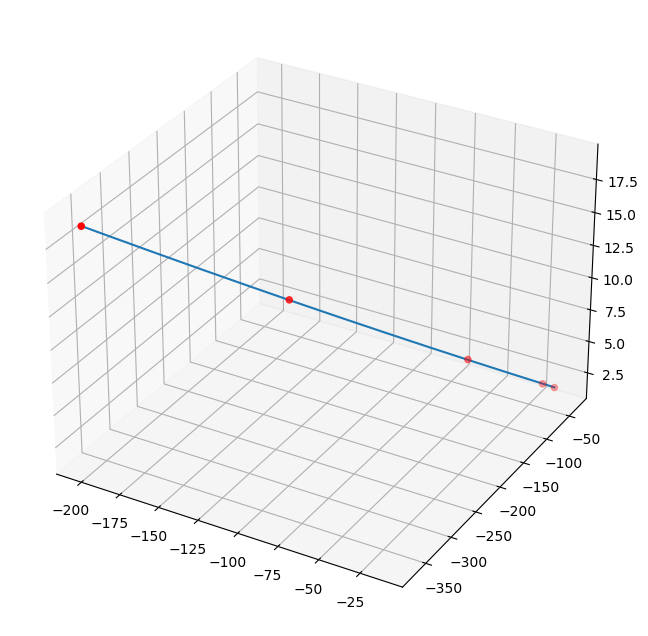

In [ ]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

track = track_hits[632]
x, y, z = track

ax.scatter(x, y, z, c="r")

x_c, y_c, R, tanl, z0, phi = fit_helix(x, y, z)

fitted_pT, fitted_pZ = momentum_from_helix(R, tanl, B)
fitted_DCA = DCA_from_helix(x_c, y_c, R)

phi0 = phi[0]
sample_phi = np.linspace(phi[0], phi[-1], 1000)
x_fit, y_fit, z_fit = helix(x_c, y_c, z0, fitted_pZ, fitted_pT, R, sample_phi)
ax.plot(x_fit, y_fit, z_fit)

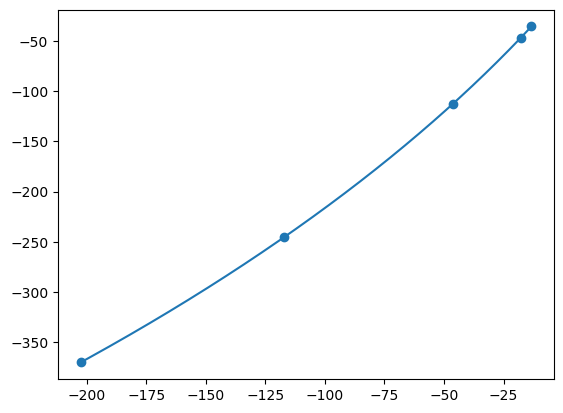

In [ ]:
plt.scatter(x, y)
plt.plot(x_fit, y_fit)

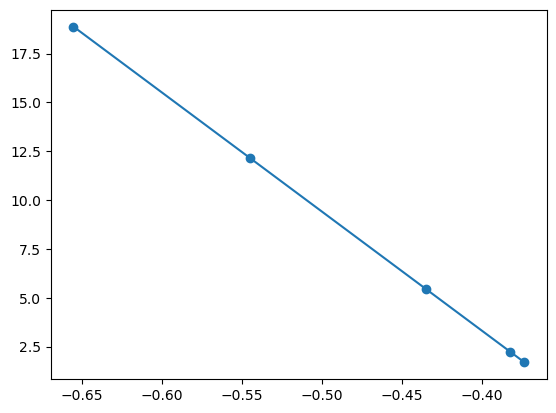

In [ ]:
plt.scatter(phi, z)
plt.plot(sample_phi, z_fit)

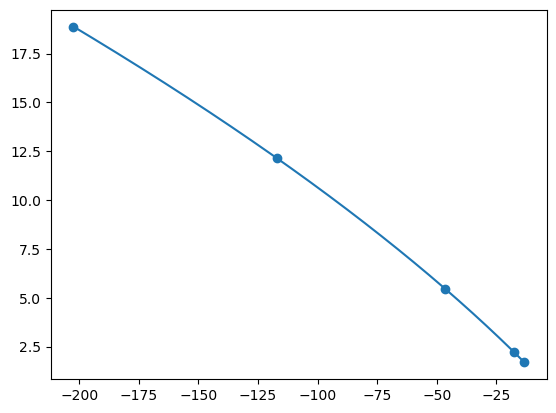

In [ ]:
plt.scatter(x, z)
plt.plot(x_fit, z_fit)